In [ ]:
from functools import reduce
import pandas as pd
from pathlib import Path

In [ ]:
PROJPATH = Path().resolve().parent
datadir = PROJPATH / "data/DDforecast_2025"
pattern = "daily_report*.csv"
filepths = sorted(list(datadir.glob(pattern)))
filepths

[PosixPath('/Users/chris/Projects/2023_Riverice/data/DDforecast_2025/daily_report_2025-03-14.csv'),
 PosixPath('/Users/chris/Projects/2023_Riverice/data/DDforecast_2025/daily_report_2025-03-15.csv'),
 PosixPath('/Users/chris/Projects/2023_Riverice/data/DDforecast_2025/daily_report_2025-03-16.csv'),
 PosixPath('/Users/chris/Projects/2023_Riverice/data/DDforecast_2025/daily_report_2025-03-17.csv'),
 PosixPath('/Users/chris/Projects/2023_Riverice/data/DDforecast_2025/daily_report_2025-03-18.csv'),
 PosixPath('/Users/chris/Projects/2023_Riverice/data/DDforecast_2025/daily_report_2025-03-19.csv'),
 PosixPath('/Users/chris/Projects/2023_Riverice/data/DDforecast_2025/daily_report_2025-03-20.csv'),
 PosixPath('/Users/chris/Projects/2023_Riverice/data/DDforecast_2025/daily_report_2025-03-21.csv'),
 PosixPath('/Users/chris/Projects/2023_Riverice/data/DDforecast_2025/daily_report_2025-03-22.csv'),
 PosixPath('/Users/chris/Projects/2023_Riverice/data/DDforecast_2025/daily_report_2025-03-23.csv'),


In [ ]:
dfs = {pth.stem[-10:]:pd.read_csv(pth)[['location', 'river', 'average breakup date', 'forecasted date']] 
       for pth in filepths}
for df in dfs:
    dfs[df].rename(columns={'forecasted date': df}, inplace=True)

In [ ]:
df_merged = reduce(lambda x, y: pd.merge(x, y, 
                                         on=['location', 'river', 'average breakup date'],
                                         how='left'), dfs.values())
# df_merged.columns = ['location', 'river', 'average breakup date'] + forcastdates
df_merged

,location,river,average breakup date,2025-03-14,2025-03-15,2025-03-16,2025-03-17,2025-03-18,2025-03-19,2025-03-20,...,2025-05-01,2025-05-02,2025-05-03,2025-05-04,2025-05-05,2025-05-06,2025-05-07,2025-05-08,2025-05-09,2025-05-27
0,Buckland,Buckland River,2025-05-17,2025-05-16,2025-05-16,2025-05-16,2025-05-16,2025-05-16,2025-05-16,2025-05-16,...,2025-05-14,2025-05-14,2025-05-13,2025-05-13,2025-05-13,2025-05-13,2025-05-13,2025-05-13,2025-05-13,2025-05-14
1,Umiat,Colville River,2025-05-24,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,...,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-22
2,Colville Village,Colville River,2025-06-01,2025-05-31,2025-05-31,2025-05-31,2025-05-31,2025-06-01,2025-06-01,2025-06-01,...,2025-05-31,2025-05-31,2025-05-31,2025-05-31,2025-05-31,2025-05-31,2025-05-31,2025-05-31,2025-05-31,2025-05-31
3,Kobuk,Kobuk River,2025-05-16,2025-05-14,2025-05-14,2025-05-14,2025-05-14,2025-05-15,2025-05-15,2025-05-15,...,2025-05-13,2025-05-13,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-13
4,Shungnak,Kobuk River,2025-05-17,2025-05-18,2025-05-17,2025-05-17,2025-05-17,2025-05-17,2025-05-17,2025-05-17,...,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-13,2025-05-14
5,Ambler,Kobuk River,2025-05-18,2025-05-17,2025-05-17,2025-05-17,2025-05-17,2025-05-17,2025-05-17,2025-05-18,...,2025-05-15,2025-05-15,2025-05-15,2025-05-14,2025-05-14,2025-05-14,2025-05-14,2025-05-14,2025-05-14,2025-05-15
6,Allakaket,Koyukuk River,2025-05-10,2025-05-09,2025-05-09,2025-05-09,2025-05-10,2025-05-10,2025-05-10,2025-05-10,...,2025-05-08,2025-05-08,2025-05-08,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-08,2025-05-09
7,Bettles,Koyukuk River,2025-05-10,2025-05-10,2025-05-10,2025-05-10,2025-05-10,2025-05-10,2025-05-10,2025-05-10,...,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-08
8,Hughes,Koyukuk River,2025-05-11,2025-05-10,2025-05-11,2025-05-11,2025-05-11,2025-05-11,2025-05-11,2025-05-11,...,2025-05-09,2025-05-09,2025-05-09,2025-05-09,2025-05-09,2025-05-08,2025-05-09,2025-05-09,2025-05-09,2025-05-10
9,Nikolai,Kuskokwim River,2025-04-23,2025-04-23,2025-04-23,2025-04-23,2025-04-22,2025-04-22,2025-04-22,2025-04-22,...,2025-04-20,NaN,2025-04-20,2025-04-20,2025-04-20,2025-04-20,NaN,2025-04-20,2025-04-20,NaN


In [ ]:
actualfpth = PROJPATH / "data/breakupdata/NWS-APRFC_AK_BreakupDate-2025.csv"
actualbreakup = pd.read_csv(actualfpth, escapechar="\\")
actualbreakup = actualbreakup[actualbreakup['year']==2025][['siteID', 'breakup']]
actualbreakup['siteID'] = actualbreakup['siteID'].str.replace(' nr ', ' at ')
actualbreakup

,siteID,breakup
0,Kuskokwim River at Nikolai,2025-04-22
1,Chena River at Fairbanks,2025-04-23
2,Yentna River at Big Bend,2025-04-23
3,Kuskokwim River at Sleetmute,2025-04-27
4,Kuskokwim River at Red Devil,2025-04-28
...,...,...
62,Selawik River at Selawik,2025-05-20
63,Colville River at Umiat,2025-06-13
64,Amber Lake at Oilwell Road,2025-05-11
65,Meade River at Atkasuk,2025-06-14


In [ ]:
actualbreakup[['river', 'location']] = actualbreakup.siteID.str.split(' at ', n=1, expand=True)

In [ ]:
actualbreakup

,siteID,breakup,river,location
0,Kuskokwim River at Nikolai,2025-04-22,Kuskokwim River,Nikolai
1,Chena River at Fairbanks,2025-04-23,Chena River,Fairbanks
2,Yentna River at Big Bend,2025-04-23,Yentna River,Big Bend
3,Kuskokwim River at Sleetmute,2025-04-27,Kuskokwim River,Sleetmute
4,Kuskokwim River at Red Devil,2025-04-28,Kuskokwim River,Red Devil
...,...,...,...,...
62,Selawik River at Selawik,2025-05-20,Selawik River,Selawik
63,Colville River at Umiat,2025-06-13,Colville River,Umiat
64,Amber Lake at Oilwell Road,2025-05-11,Amber Lake,Oilwell Road
65,Meade River at Atkasuk,2025-06-14,Meade River,Atkasuk


In [ ]:
evalDF = pd.merge(left=df_merged, right=actualbreakup, left_on=['river', 'location'], right_on=['river', 'location'])
evalDF

,location,river,average breakup date,2025-03-14,2025-03-15,2025-03-16,2025-03-17,2025-03-18,2025-03-19,2025-03-20,...,2025-05-03,2025-05-04,2025-05-05,2025-05-06,2025-05-07,2025-05-08,2025-05-09,2025-05-27,siteID,breakup
0,Buckland,Buckland River,2025-05-17,2025-05-16,2025-05-16,2025-05-16,2025-05-16,2025-05-16,2025-05-16,2025-05-16,...,2025-05-13,2025-05-13,2025-05-13,2025-05-13,2025-05-13,2025-05-13,2025-05-13,2025-05-14,Buckland River at Buckland,2025-05-15
1,Umiat,Colville River,2025-05-24,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,...,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-21,2025-05-22,Colville River at Umiat,2025-06-13
2,Kobuk,Kobuk River,2025-05-16,2025-05-14,2025-05-14,2025-05-14,2025-05-14,2025-05-15,2025-05-15,2025-05-15,...,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-13,Kobuk River at Kobuk,2025-05-16
3,Shungnak,Kobuk River,2025-05-17,2025-05-18,2025-05-17,2025-05-17,2025-05-17,2025-05-17,2025-05-17,2025-05-17,...,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-12,2025-05-13,2025-05-14,Kobuk River at Shungnak,2025-05-16
4,Ambler,Kobuk River,2025-05-18,2025-05-17,2025-05-17,2025-05-17,2025-05-17,2025-05-17,2025-05-17,2025-05-18,...,2025-05-15,2025-05-14,2025-05-14,2025-05-14,2025-05-14,2025-05-14,2025-05-14,2025-05-15,Kobuk River at Ambler,2025-05-22
5,Allakaket,Koyukuk River,2025-05-10,2025-05-09,2025-05-09,2025-05-09,2025-05-10,2025-05-10,2025-05-10,2025-05-10,...,2025-05-08,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-08,2025-05-09,Koyukuk River at Allakaket,2025-05-12
6,Bettles,Koyukuk River,2025-05-10,2025-05-10,2025-05-10,2025-05-10,2025-05-10,2025-05-10,2025-05-10,2025-05-10,...,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-07,2025-05-08,Koyukuk River at Bettles,2025-05-16
7,Hughes,Koyukuk River,2025-05-11,2025-05-10,2025-05-11,2025-05-11,2025-05-11,2025-05-11,2025-05-11,2025-05-11,...,2025-05-09,2025-05-09,2025-05-09,2025-05-08,2025-05-09,2025-05-09,2025-05-09,2025-05-10,Koyukuk River at Hughes,2025-05-13
8,Nikolai,Kuskokwim River,2025-04-23,2025-04-23,2025-04-23,2025-04-23,2025-04-22,2025-04-22,2025-04-22,2025-04-22,...,2025-04-20,2025-04-20,2025-04-20,2025-04-20,NaN,2025-04-20,2025-04-20,NaN,Kuskokwim River at Nikolai,2025-04-22
9,Sleetmute,Kuskokwim River,2025-05-04,2025-05-07,2025-05-06,2025-05-06,2025-05-06,2025-05-05,2025-05-04,2025-05-04,...,2025-05-01,2025-05-01,2025-05-01,2025-05-01,NaN,2025-05-01,2025-05-01,NaN,Kuskokwim River at Sleetmute,2025-04-27


In [ ]:
evalDF.columns

Index(['location', 'river', 'average breakup date', '2025-03-14', '2025-03-15',
       '2025-03-16', '2025-03-17', '2025-03-18', '2025-03-19', '2025-03-20',
       '2025-03-21', '2025-03-22', '2025-03-23', '2025-03-24', '2025-03-25',
       '2025-03-26', '2025-03-27', '2025-03-28', '2025-03-29', '2025-03-30',
       '2025-03-31', '2025-04-01', '2025-04-02', '2025-04-03', '2025-04-04',
       '2025-04-05', '2025-04-06', '2025-04-07', '2025-04-08', '2025-04-09',
       '2025-04-10', '2025-04-11', '2025-04-12', '2025-04-13', '2025-04-14',
       '2025-04-15', '2025-04-16', '2025-04-17', '2025-04-18', '2025-04-19',
       '2025-04-20', '2025-04-21', '2025-04-22', '2025-04-23', '2025-04-24',
       '2025-04-25', '2025-04-26', '2025-04-27', '2025-04-28', '2025-04-29',
       '2025-04-30', '2025-05-01', '2025-05-02', '2025-05-03', '2025-05-04',
       '2025-05-05', '2025-05-06', '2025-05-07', '2025-05-08', '2025-05-09',
       '2025-05-27', 'siteID', 'breakup'],
      dtype='object')

In [ ]:
for col in ['2025-03-14', '2025-03-15',
       '2025-03-16', '2025-03-17', '2025-03-18', '2025-03-19', '2025-03-20',
       '2025-03-21', '2025-03-22', '2025-03-23', '2025-03-24', '2025-03-25',
       '2025-03-26', '2025-03-27', '2025-03-28', '2025-03-29', '2025-03-30',
       '2025-03-31', '2025-04-01', '2025-04-02', '2025-04-03', '2025-04-04',
       '2025-04-05', '2025-04-06', '2025-04-07', '2025-04-08', '2025-04-09',
       '2025-04-10', '2025-04-11', '2025-04-12', '2025-04-13', '2025-04-14',
       '2025-04-15', '2025-04-16', '2025-04-17', '2025-04-18', '2025-04-19',
       '2025-04-20', '2025-04-21', '2025-04-22', '2025-04-23', '2025-04-24',
       '2025-04-25', '2025-04-26', '2025-04-27', '2025-04-28', '2025-04-29',
       '2025-04-30', '2025-05-01', '2025-05-02', '2025-05-03', '2025-05-04',
       '2025-05-05', '2025-05-06', '2025-05-07', '2025-05-08', '2025-05-09',
       '2025-05-27',]:
       evalDF[col] = (pd.to_datetime(evalDF[col]) - pd.to_datetime(evalDF['breakup'])).dt.days
       

In [ ]:
evalDF

,location,river,average breakup date,2025-03-14,2025-03-15,2025-03-16,2025-03-17,2025-03-18,2025-03-19,2025-03-20,...,2025-05-03,2025-05-04,2025-05-05,2025-05-06,2025-05-07,2025-05-08,2025-05-09,2025-05-27,siteID,breakup
0,Buckland,Buckland River,2025-05-17,1,1,1,1,1,1,1,...,-2,-2,-2,-2,-2.0,-2,-2,-1.0,Buckland River at Buckland,2025-05-15
1,Umiat,Colville River,2025-05-24,-23,-23,-23,-23,-23,-23,-23,...,-23,-23,-23,-23,-23.0,-23,-23,-22.0,Colville River at Umiat,2025-06-13
2,Kobuk,Kobuk River,2025-05-16,-2,-2,-2,-2,-1,-1,-1,...,-4,-4,-4,-4,-4.0,-4,-4,-3.0,Kobuk River at Kobuk,2025-05-16
3,Shungnak,Kobuk River,2025-05-17,2,1,1,1,1,1,1,...,-4,-4,-4,-4,-4.0,-4,-3,-2.0,Kobuk River at Shungnak,2025-05-16
4,Ambler,Kobuk River,2025-05-18,-5,-5,-5,-5,-5,-5,-4,...,-7,-8,-8,-8,-8.0,-8,-8,-7.0,Kobuk River at Ambler,2025-05-22
5,Allakaket,Koyukuk River,2025-05-10,-3,-3,-3,-2,-2,-2,-2,...,-4,-5,-5,-5,-5.0,-5,-4,-3.0,Koyukuk River at Allakaket,2025-05-12
6,Bettles,Koyukuk River,2025-05-10,-6,-6,-6,-6,-6,-6,-6,...,-9,-9,-9,-9,-9.0,-9,-9,-8.0,Koyukuk River at Bettles,2025-05-16
7,Hughes,Koyukuk River,2025-05-11,-3,-2,-2,-2,-2,-2,-2,...,-4,-4,-4,-5,-4.0,-4,-4,-3.0,Koyukuk River at Hughes,2025-05-13
8,Nikolai,Kuskokwim River,2025-04-23,1,1,1,0,0,0,0,...,-2,-2,-2,-2,NaN,-2,-2,NaN,Kuskokwim River at Nikolai,2025-04-22
9,Sleetmute,Kuskokwim River,2025-05-04,10,9,9,9,8,7,7,...,4,4,4,4,NaN,4,4,NaN,Kuskokwim River at Sleetmute,2025-04-27


In [ ]:
evalDF_transposed = evalDF.drop(columns=['location', 'river', 'average breakup date', 'breakup']).T
evalDF_transposed.columns = evalDF_transposed.loc['siteID']
evalDF_transposed.drop(labels='siteID', axis=0)


siteID,Buckland River at Buckland,Colville River at Umiat,Kobuk River at Kobuk,Kobuk River at Shungnak,Kobuk River at Ambler,Koyukuk River at Allakaket,Koyukuk River at Bettles,Koyukuk River at Hughes,Kuskokwim River at Nikolai,Kuskokwim River at Sleetmute,...,Yukon River at Stevens Village,Yukon River at Holy Cross,Yukon River at Kaltag,Yukon River at Marshall,Yukon River at Pilot Station,Yukon River at Russian Mission,Yukon River at Anvik,Yukon River at Mountain Village,Yukon River at Emmonak,Yukon River at Alakanuk
2025-03-14,1,-23,-2,2,-5,-3,-6,-3,1,10,...,-4,2,4,3,3,3,6,2,4,5
2025-03-15,1,-23,-2,1,-5,-3,-6,-2,1,9,...,-4,2,4,3,3,3,5,2,4,5
2025-03-16,1,-23,-2,1,-5,-3,-6,-2,1,9,...,-4,2,4,3,3,3,5,2,4,5
2025-03-17,1,-23,-2,1,-5,-2,-6,-2,0,9,...,-3,2,4,3,3,2,5,2,4,5
2025-03-18,1,-23,-1,1,-5,-2,-6,-2,0,8,...,-3,2,4,3,3,2,5,2,4,5
2025-03-19,1,-23,-1,1,-5,-2,-6,-2,0,7,...,-3,2,4,3,3,2,5,2,4,5
2025-03-20,1,-23,-1,1,-4,-2,-6,-2,0,7,...,-3,2,4,3,3,2,5,3,4,5
2025-03-21,2,-23,0,1,-4,-2,-6,-2,0,7,...,-3,2,4,3,3,2,5,3,4,5
2025-03-22,2,-23,0,1,-4,-2,-6,-2,0,7,...,-3,2,4,3,3,2,5,3,4,5
2025-03-23,2,-22,0,1,-4,-2,-6,-2,0,7,...,-2,2,4,3,3,2,5,3,4,5


In [ ]:
evalDF.to_csv("eval_2025.csv")

### plotting

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
evalDF = pd.read_csv("eval_2025.csv", index_col=0)
evalDF_transposed = evalDF.drop(columns=['location', 'river', 'average breakup date', 'breakup']).T
evalDF_transposed.columns = evalDF_transposed.loc['siteID']
evalDF_transposed.drop(labels='siteID', axis=0)

siteID,Buckland River at Buckland,Colville River at Umiat,Kobuk River at Kobuk,Kobuk River at Shungnak,Kobuk River at Ambler,Koyukuk River at Allakaket,Koyukuk River at Bettles,Koyukuk River at Hughes,Kuskokwim River at Nikolai,Kuskokwim River at Sleetmute,...,Yukon River at Stevens Village,Yukon River at Holy Cross,Yukon River at Kaltag,Yukon River at Marshall,Yukon River at Pilot Station,Yukon River at Russian Mission,Yukon River at Anvik,Yukon River at Mountain Village,Yukon River at Emmonak,Yukon River at Alakanuk
2025-03-14,1,-23,-2,2,-5,-3,-6,-3,1,10,...,-4,2,4,3,3,3,6,2,4,5
2025-03-15,1,-23,-2,1,-5,-3,-6,-2,1,9,...,-4,2,4,3,3,3,5,2,4,5
2025-03-16,1,-23,-2,1,-5,-3,-6,-2,1,9,...,-4,2,4,3,3,3,5,2,4,5
2025-03-17,1,-23,-2,1,-5,-2,-6,-2,0,9,...,-3,2,4,3,3,2,5,2,4,5
2025-03-18,1,-23,-1,1,-5,-2,-6,-2,0,8,...,-3,2,4,3,3,2,5,2,4,5
2025-03-19,1,-23,-1,1,-5,-2,-6,-2,0,7,...,-3,2,4,3,3,2,5,2,4,5
2025-03-20,1,-23,-1,1,-4,-2,-6,-2,0,7,...,-3,2,4,3,3,2,5,3,4,5
2025-03-21,2,-23,0,1,-4,-2,-6,-2,0,7,...,-3,2,4,3,3,2,5,3,4,5
2025-03-22,2,-23,0,1,-4,-2,-6,-2,0,7,...,-3,2,4,3,3,2,5,3,4,5
2025-03-23,2,-22,0,1,-4,-2,-6,-2,0,7,...,-2,2,4,3,3,2,5,3,4,5


In [ ]:
evalDF

,location,river,average breakup date,2025-03-14,2025-03-15,2025-03-16,2025-03-17,2025-03-18,2025-03-19,2025-03-20,...,2025-05-03,2025-05-04,2025-05-05,2025-05-06,2025-05-07,2025-05-08,2025-05-09,2025-05-27,siteID,breakup
0,Buckland,Buckland River,2025-05-17,1,1,1,1,1,1,1,...,-2,-2,-2,-2,-2.0,-2,-2,-1.0,Buckland River at Buckland,2025-05-15
1,Umiat,Colville River,2025-05-24,-23,-23,-23,-23,-23,-23,-23,...,-23,-23,-23,-23,-23.0,-23,-23,-22.0,Colville River at Umiat,2025-06-13
2,Kobuk,Kobuk River,2025-05-16,-2,-2,-2,-2,-1,-1,-1,...,-4,-4,-4,-4,-4.0,-4,-4,-3.0,Kobuk River at Kobuk,2025-05-16
3,Shungnak,Kobuk River,2025-05-17,2,1,1,1,1,1,1,...,-4,-4,-4,-4,-4.0,-4,-3,-2.0,Kobuk River at Shungnak,2025-05-16
4,Ambler,Kobuk River,2025-05-18,-5,-5,-5,-5,-5,-5,-4,...,-7,-8,-8,-8,-8.0,-8,-8,-7.0,Kobuk River at Ambler,2025-05-22
5,Allakaket,Koyukuk River,2025-05-10,-3,-3,-3,-2,-2,-2,-2,...,-4,-5,-5,-5,-5.0,-5,-4,-3.0,Koyukuk River at Allakaket,2025-05-12
6,Bettles,Koyukuk River,2025-05-10,-6,-6,-6,-6,-6,-6,-6,...,-9,-9,-9,-9,-9.0,-9,-9,-8.0,Koyukuk River at Bettles,2025-05-16
7,Hughes,Koyukuk River,2025-05-11,-3,-2,-2,-2,-2,-2,-2,...,-4,-4,-4,-5,-4.0,-4,-4,-3.0,Koyukuk River at Hughes,2025-05-13
8,Nikolai,Kuskokwim River,2025-04-23,1,1,1,0,0,0,0,...,-2,-2,-2,-2,NaN,-2,-2,NaN,Kuskokwim River at Nikolai,2025-04-22
9,Sleetmute,Kuskokwim River,2025-05-04,10,9,9,9,8,7,7,...,4,4,4,4,NaN,4,4,NaN,Kuskokwim River at Sleetmute,2025-04-27


In [ ]:
plotDF = evalDF_transposed.drop(labels='siteID', axis=0).astype(float)

In [ ]:
sns.set_context('paper')
cmap = sns.color_palette("coolwarm", 12)

Text(0.5, 1.0, '2025 forecast error (days)')

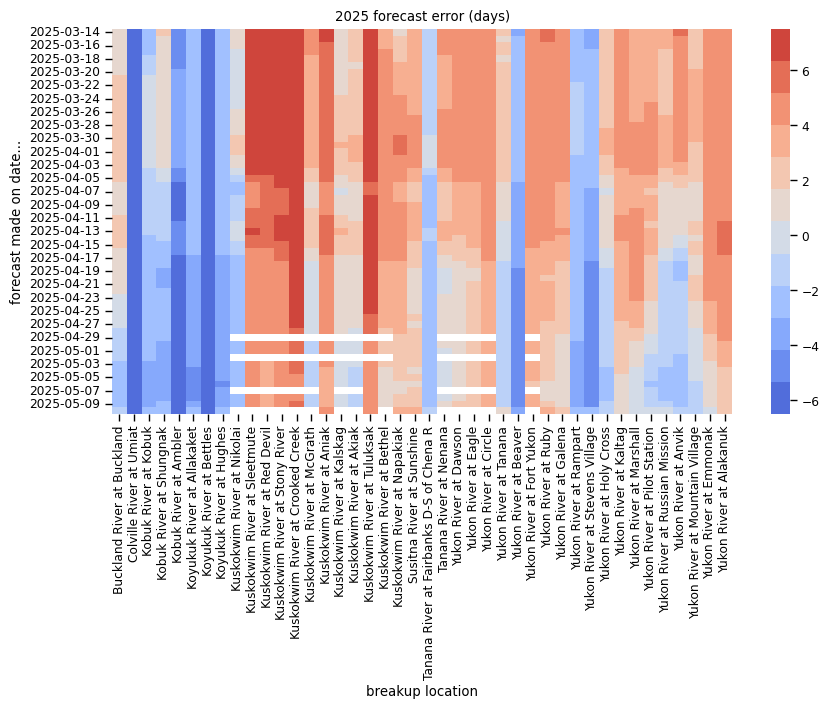

In [ ]:
figure = plt.figure(figsize=(10, 5))
sns.heatmap(plotDF, cmap=cmap, 
            vmax=7.5, vmin=-6.5
            )
plt.ylabel('forecast made on date...')
plt.xlabel('breakup location')
plt.title('2025 forecast error (days)')

In [ ]:
evalDF

,location,river,average breakup date,2025-03-14,2025-03-15,2025-03-16,2025-03-17,2025-03-18,2025-03-19,2025-03-20,...,2025-05-03,2025-05-04,2025-05-05,2025-05-06,2025-05-07,2025-05-08,2025-05-09,2025-05-27,siteID,breakup
0,Buckland,Buckland River,2025-05-17,1,1,1,1,1,1,1,...,-2,-2,-2,-2,-2.0,-2,-2,-1.0,Buckland River at Buckland,2025-05-15
1,Umiat,Colville River,2025-05-24,-23,-23,-23,-23,-23,-23,-23,...,-23,-23,-23,-23,-23.0,-23,-23,-22.0,Colville River at Umiat,2025-06-13
2,Kobuk,Kobuk River,2025-05-16,-2,-2,-2,-2,-1,-1,-1,...,-4,-4,-4,-4,-4.0,-4,-4,-3.0,Kobuk River at Kobuk,2025-05-16
3,Shungnak,Kobuk River,2025-05-17,2,1,1,1,1,1,1,...,-4,-4,-4,-4,-4.0,-4,-3,-2.0,Kobuk River at Shungnak,2025-05-16
4,Ambler,Kobuk River,2025-05-18,-5,-5,-5,-5,-5,-5,-4,...,-7,-8,-8,-8,-8.0,-8,-8,-7.0,Kobuk River at Ambler,2025-05-22
5,Allakaket,Koyukuk River,2025-05-10,-3,-3,-3,-2,-2,-2,-2,...,-4,-5,-5,-5,-5.0,-5,-4,-3.0,Koyukuk River at Allakaket,2025-05-12
6,Bettles,Koyukuk River,2025-05-10,-6,-6,-6,-6,-6,-6,-6,...,-9,-9,-9,-9,-9.0,-9,-9,-8.0,Koyukuk River at Bettles,2025-05-16
7,Hughes,Koyukuk River,2025-05-11,-3,-2,-2,-2,-2,-2,-2,...,-4,-4,-4,-5,-4.0,-4,-4,-3.0,Koyukuk River at Hughes,2025-05-13
8,Nikolai,Kuskokwim River,2025-04-23,1,1,1,0,0,0,0,...,-2,-2,-2,-2,NaN,-2,-2,NaN,Kuskokwim River at Nikolai,2025-04-22
9,Sleetmute,Kuskokwim River,2025-05-04,10,9,9,9,8,7,7,...,4,4,4,4,NaN,4,4,NaN,Kuskokwim River at Sleetmute,2025-04-27


In [ ]:
evalDF = evalDF.ffill(axis=1)

In [ ]:
evalDF

,location,river,average breakup date,2025-03-14,2025-03-15,2025-03-16,2025-03-17,2025-03-18,2025-03-19,2025-03-20,...,2025-05-03,2025-05-04,2025-05-05,2025-05-06,2025-05-07,2025-05-08,2025-05-09,2025-05-27,siteID,breakup
0,Buckland,Buckland River,2025-05-17,1,1,1,1,1,1,1,...,-2,-2,-2,-2,-2.0,-2,-2,-1.0,Buckland River at Buckland,2025-05-15
1,Umiat,Colville River,2025-05-24,-23,-23,-23,-23,-23,-23,-23,...,-23,-23,-23,-23,-23.0,-23,-23,-22.0,Colville River at Umiat,2025-06-13
2,Kobuk,Kobuk River,2025-05-16,-2,-2,-2,-2,-1,-1,-1,...,-4,-4,-4,-4,-4.0,-4,-4,-3.0,Kobuk River at Kobuk,2025-05-16
3,Shungnak,Kobuk River,2025-05-17,2,1,1,1,1,1,1,...,-4,-4,-4,-4,-4.0,-4,-3,-2.0,Kobuk River at Shungnak,2025-05-16
4,Ambler,Kobuk River,2025-05-18,-5,-5,-5,-5,-5,-5,-4,...,-7,-8,-8,-8,-8.0,-8,-8,-7.0,Kobuk River at Ambler,2025-05-22
5,Allakaket,Koyukuk River,2025-05-10,-3,-3,-3,-2,-2,-2,-2,...,-4,-5,-5,-5,-5.0,-5,-4,-3.0,Koyukuk River at Allakaket,2025-05-12
6,Bettles,Koyukuk River,2025-05-10,-6,-6,-6,-6,-6,-6,-6,...,-9,-9,-9,-9,-9.0,-9,-9,-8.0,Koyukuk River at Bettles,2025-05-16
7,Hughes,Koyukuk River,2025-05-11,-3,-2,-2,-2,-2,-2,-2,...,-4,-4,-4,-5,-4.0,-4,-4,-3.0,Koyukuk River at Hughes,2025-05-13
8,Nikolai,Kuskokwim River,2025-04-23,1,1,1,0,0,0,0,...,-2,-2,-2,-2,-2,-2,-2,-2,Kuskokwim River at Nikolai,2025-04-22
9,Sleetmute,Kuskokwim River,2025-05-04,10,9,9,9,8,7,7,...,4,4,4,4,4,4,4,4,Kuskokwim River at Sleetmute,2025-04-27


In [ ]:
evalDF_transposed = evalDF_transposed.ffill()

In [ ]:
evalDF_transposed.drop(labels='siteID', axis=0).mean()

siteID
Buckland River at Buckland                   0.706897
Colville River at Umiat                    -22.534483
Kobuk River at Kobuk                        -1.810345
Kobuk River at Shungnak                     -1.275862
Kobuk River at Ambler                       -5.586207
Koyukuk River at Allakaket                  -3.155172
Koyukuk River at Bettles                    -7.293103
Koyukuk River at Hughes                     -3.068966
Kuskokwim River at Nikolai                  -0.775862
Kuskokwim River at Sleetmute                 5.758621
Kuskokwim River at Red Devil                 5.551724
Kuskokwim River at Stony River               6.413793
Kuskokwim River at Crooked Creek             7.396552
Kuskokwim River at McGrath                   1.362069
Kuskokwim River at Aniak                     5.206897
Kuskokwim River at Kalskag                   1.137931
Kuskokwim River at Akiak                     1.189655
Kuskokwim River at Tuluksak                  6.534483
Kuskokwim River at Be

In [ ]:
evalDF.river.value_counts()

river
Yukon River        19
Kuskokwim River    12
Kobuk River         3
Koyukuk River       3
Tanana River        2
Buckland River      1
Colville River      1
Susitna River       1
Name: count, dtype: int64

In [ ]:
evalDF

,location,river,average breakup date,2025-03-14,2025-03-15,2025-03-16,2025-03-17,2025-03-18,2025-03-19,2025-03-20,...,2025-05-03,2025-05-04,2025-05-05,2025-05-06,2025-05-07,2025-05-08,2025-05-09,2025-05-27,siteID,breakup
0,Buckland,Buckland River,2025-05-17,1,1,1,1,1,1,1,...,-2,-2,-2,-2,-2.0,-2,-2,-1.0,Buckland River at Buckland,2025-05-15
1,Umiat,Colville River,2025-05-24,-23,-23,-23,-23,-23,-23,-23,...,-23,-23,-23,-23,-23.0,-23,-23,-22.0,Colville River at Umiat,2025-06-13
2,Kobuk,Kobuk River,2025-05-16,-2,-2,-2,-2,-1,-1,-1,...,-4,-4,-4,-4,-4.0,-4,-4,-3.0,Kobuk River at Kobuk,2025-05-16
3,Shungnak,Kobuk River,2025-05-17,2,1,1,1,1,1,1,...,-4,-4,-4,-4,-4.0,-4,-3,-2.0,Kobuk River at Shungnak,2025-05-16
4,Ambler,Kobuk River,2025-05-18,-5,-5,-5,-5,-5,-5,-4,...,-7,-8,-8,-8,-8.0,-8,-8,-7.0,Kobuk River at Ambler,2025-05-22
5,Allakaket,Koyukuk River,2025-05-10,-3,-3,-3,-2,-2,-2,-2,...,-4,-5,-5,-5,-5.0,-5,-4,-3.0,Koyukuk River at Allakaket,2025-05-12
6,Bettles,Koyukuk River,2025-05-10,-6,-6,-6,-6,-6,-6,-6,...,-9,-9,-9,-9,-9.0,-9,-9,-8.0,Koyukuk River at Bettles,2025-05-16
7,Hughes,Koyukuk River,2025-05-11,-3,-2,-2,-2,-2,-2,-2,...,-4,-4,-4,-5,-4.0,-4,-4,-3.0,Koyukuk River at Hughes,2025-05-13
8,Nikolai,Kuskokwim River,2025-04-23,1,1,1,0,0,0,0,...,-2,-2,-2,-2,-2,-2,-2,-2,Kuskokwim River at Nikolai,2025-04-22
9,Sleetmute,Kuskokwim River,2025-05-04,10,9,9,9,8,7,7,...,4,4,4,4,4,4,4,4,Kuskokwim River at Sleetmute,2025-04-27


Text(0.5, 1.0, 'average forecast error')

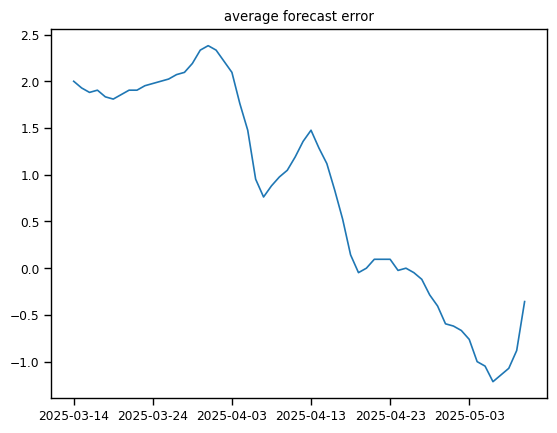

In [ ]:
evalDF.drop(columns=['location', 'river', 'average breakup date', 'siteID', 'breakup']).mean(axis=0).plot()
plt.title("average forecast error")

In [ ]:
evalDF.columns

Index(['location', 'river', 'average breakup date', '2025-03-14', '2025-03-15',
       '2025-03-16', '2025-03-17', '2025-03-18', '2025-03-19', '2025-03-20',
       '2025-03-21', '2025-03-22', '2025-03-23', '2025-03-24', '2025-03-25',
       '2025-03-26', '2025-03-27', '2025-03-28', '2025-03-29', '2025-03-30',
       '2025-03-31', '2025-04-01', '2025-04-02', '2025-04-03', '2025-04-04',
       '2025-04-05', '2025-04-06', '2025-04-07', '2025-04-08', '2025-04-09',
       '2025-04-10', '2025-04-11', '2025-04-12', '2025-04-13', '2025-04-14',
       '2025-04-15', '2025-04-16', '2025-04-17', '2025-04-18', '2025-04-19',
       '2025-04-20', '2025-04-21', '2025-04-22', '2025-04-23', '2025-04-24',
       '2025-04-25', '2025-04-26', '2025-04-27', '2025-04-28', '2025-04-29',
       '2025-04-30', '2025-05-01', '2025-05-02', '2025-05-03', '2025-05-04',
       '2025-05-05', '2025-05-06', '2025-05-07', '2025-05-08', '2025-05-09',
       '2025-05-27', 'siteID', 'breakup'],
      dtype='object')

In [ ]:
evalDF_transposed.drop(labels='siteID', axis=0).reset_index().melt(
    'index', var_name='location', 
    value_name='forecast error (days)')

,index,location,forecast error (days)
0,2025-03-14,Buckland River at Buckland,1
1,2025-03-15,Buckland River at Buckland,1
2,2025-03-16,Buckland River at Buckland,1
3,2025-03-17,Buckland River at Buckland,1
4,2025-03-18,Buckland River at Buckland,1
...,...,...,...
2431,2025-05-06,Yukon River at Alakanuk,2
2432,2025-05-07,Yukon River at Alakanuk,2.0
2433,2025-05-08,Yukon River at Alakanuk,2
2434,2025-05-09,Yukon River at Alakanuk,2


In [ ]:
evalDF['avg_error'] = evalDF.drop(columns=['location', 'river', 'average breakup date', 'siteID', 'breakup']).mean(axis=1)
evalDF[['river', 'avg_error']].groupby(by='river').mean()

,avg_error
river,
Buckland River,0.706897
Colville River,-22.534483
Kobuk River,-2.890805
Koyukuk River,-4.505747
Kuskokwim River,3.877874
Susitna River,2.482759
Tanana River,0.103448
Yukon River,1.573503


In [ ]:
evalDF[['river', 'avg_error']].groupby(by='river').std()

,avg_error
river,
Buckland River,NaN
Colville River,NaN
Kobuk River,2.349535
Koyukuk River,2.414306
Kuskokwim River,2.649145
Susitna River,NaN
Tanana River,2.779661
Yukon River,2.543471


In [ ]:
evalDF

,location,river,average breakup date,2025-03-14,2025-03-15,2025-03-16,2025-03-17,2025-03-18,2025-03-19,2025-03-20,...,2025-05-04,2025-05-05,2025-05-06,2025-05-07,2025-05-08,2025-05-09,2025-05-27,siteID,breakup,avg_error
0,Buckland,Buckland River,2025-05-17,1,1,1,1,1,1,1,...,-2,-2,-2,-2.0,-2,-2,-1.0,Buckland River at Buckland,2025-05-15,0.706897
1,Umiat,Colville River,2025-05-24,-23,-23,-23,-23,-23,-23,-23,...,-23,-23,-23,-23.0,-23,-23,-22.0,Colville River at Umiat,2025-06-13,-22.534483
2,Kobuk,Kobuk River,2025-05-16,-2,-2,-2,-2,-1,-1,-1,...,-4,-4,-4,-4.0,-4,-4,-3.0,Kobuk River at Kobuk,2025-05-16,-1.810345
3,Shungnak,Kobuk River,2025-05-17,2,1,1,1,1,1,1,...,-4,-4,-4,-4.0,-4,-3,-2.0,Kobuk River at Shungnak,2025-05-16,-1.275862
4,Ambler,Kobuk River,2025-05-18,-5,-5,-5,-5,-5,-5,-4,...,-8,-8,-8,-8.0,-8,-8,-7.0,Kobuk River at Ambler,2025-05-22,-5.586207
5,Allakaket,Koyukuk River,2025-05-10,-3,-3,-3,-2,-2,-2,-2,...,-5,-5,-5,-5.0,-5,-4,-3.0,Koyukuk River at Allakaket,2025-05-12,-3.155172
6,Bettles,Koyukuk River,2025-05-10,-6,-6,-6,-6,-6,-6,-6,...,-9,-9,-9,-9.0,-9,-9,-8.0,Koyukuk River at Bettles,2025-05-16,-7.293103
7,Hughes,Koyukuk River,2025-05-11,-3,-2,-2,-2,-2,-2,-2,...,-4,-4,-5,-4.0,-4,-4,-3.0,Koyukuk River at Hughes,2025-05-13,-3.068966
8,Nikolai,Kuskokwim River,2025-04-23,1,1,1,0,0,0,0,...,-2,-2,-2,-2,-2,-2,-2,Kuskokwim River at Nikolai,2025-04-22,-0.775862
9,Sleetmute,Kuskokwim River,2025-05-04,10,9,9,9,8,7,7,...,4,4,4,4,4,4,4,Kuskokwim River at Sleetmute,2025-04-27,5.758621


In [ ]:
evalDF[evalDF.river.isin(['Yukon River', 'Kuskokwim River'])].drop(columns=['location', 'siteID', 'avg_error', 'average breakup date', 'breakup'])

,river,2025-03-14,2025-03-15,2025-03-16,2025-03-17,2025-03-18,2025-03-19,2025-03-20,2025-03-21,2025-03-22,...,2025-05-01,2025-05-02,2025-05-03,2025-05-04,2025-05-05,2025-05-06,2025-05-07,2025-05-08,2025-05-09,2025-05-27
8,Kuskokwim River,1,1,1,0,0,0,0,0,0,...,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2
9,Kuskokwim River,10,9,9,9,8,7,7,7,7,...,4,4,4,4,4,4,4,4,4,4
10,Kuskokwim River,8,8,8,7,7,7,7,7,7,...,4,4,3,3,3,3,3,3,3,3
11,Kuskokwim River,10,10,9,9,9,9,8,8,8,...,4,4,4,4,4,4,4,4,4,4
12,Kuskokwim River,8,8,8,8,8,8,8,8,8,...,6,6,6,6,5,5,5,5,6,6
13,Kuskokwim River,5,4,4,4,3,3,3,3,3,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
14,Kuskokwim River,7,7,6,6,6,6,6,6,6,...,4,4,4,3,3,3,3.0,3,3,4.0
15,Kuskokwim River,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
16,Kuskokwim River,2,2,2,2,2,1,2,2,2,...,0,0,0,-1,-1,-1,-1,-1,-1,-1
17,Kuskokwim River,7,7,7,7,7,7,7,7,7,...,5,5,5,5,4,4,4.0,4,4,4.0


In [ ]:
data = evalDF.drop(
    columns=['location', 'siteID', 'avg_error', 'average breakup date', 'breakup'])
# data = evalDF[evalDF.river.isin(['Yukon River', 'Kuskokwim River'])].drop(
#     columns=['location', 'siteID', 'avg_error', 'average breakup date', 'breakup'])
data = data.melt('river', var_name='forecast day', 
    value_name='forecast error (days)')

In [ ]:
data

,river,forecast day,forecast error (days)
0,Buckland River,2025-03-14,1
1,Colville River,2025-03-14,-23
2,Kobuk River,2025-03-14,-2
3,Kobuk River,2025-03-14,2
4,Kobuk River,2025-03-14,-5
...,...,...,...
2431,Yukon River,2025-05-27,0.0
2432,Yukon River,2025-05-27,-1.0
2433,Yukon River,2025-05-27,-1.0
2434,Yukon River,2025-05-27,0.0


/Users/chris/mambaforge/envs/aprfc_breakup/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/chris/mambaforge/envs/aprfc_breakup/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 26.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/chris/mambaforge/envs/aprfc_breakup/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 41.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/chris/mambaforge/envs/aprfc_breakup/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 74.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, U

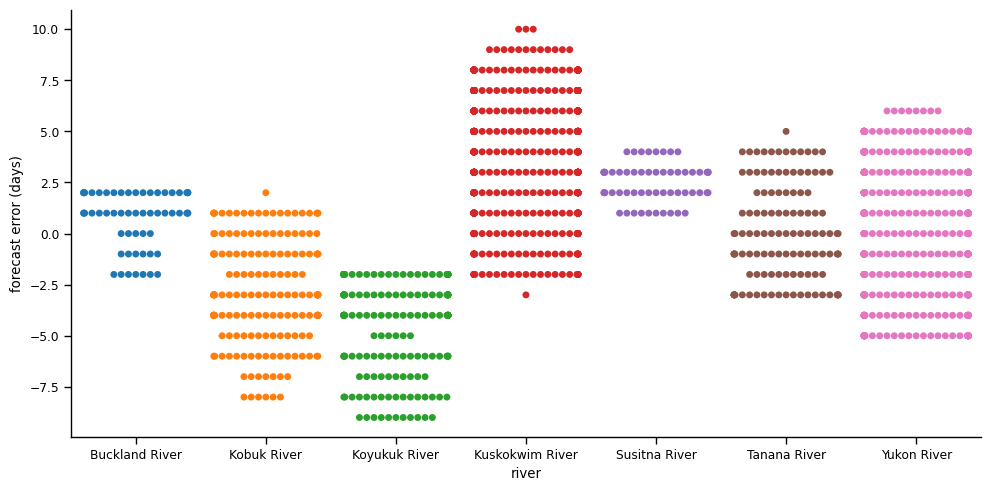

In [ ]:
sns.catplot(data=data[data.river!="Colville River"], kind="swarm", x='river', y='forecast error (days)', hue='river', aspect=2)

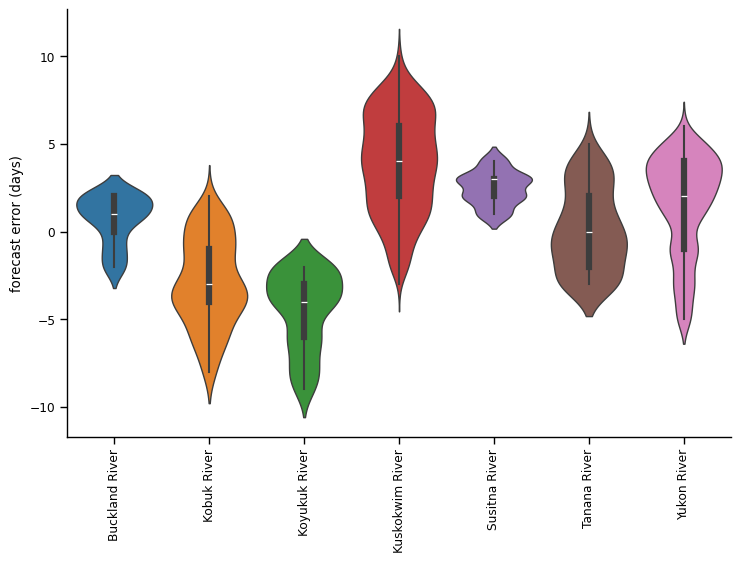

In [ ]:
ax = sns.catplot(
    data=data[data.river!="Colville River"], kind="violin", x='river', y='forecast error (days)', hue='river',
    aspect=1.5)
sns.axes_style('whitegrid')
ax.tick_params(axis='x', rotation=90)
ax.set_xlabels('')

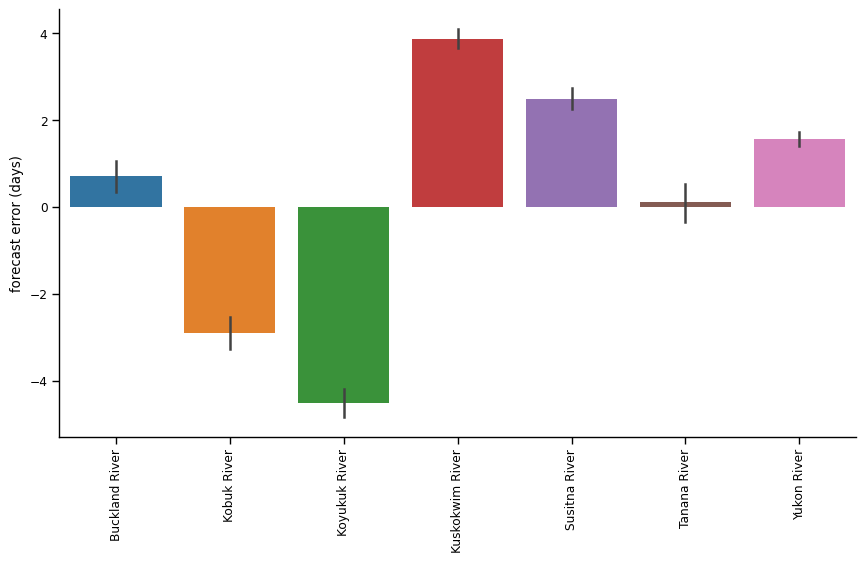

In [ ]:
ax = sns.catplot(
    data=data[data.river!="Colville River"], kind="bar", x='river', y='forecast error (days)', hue='river',
    aspect=1.75)
ax.tick_params(axis='x', rotation=90)
ax.set_xlabels('')